# HopeEXP — Task A: Clasificación de Etiqueta Primaria
**Modelo base:** `microsoft/mdeberta-v3-base`  
**Tipo de tarea:** Clasificación monolabel (6 clases)  
**Clases:** General Hope, Realistic Hope, Unrealistic Hope, Sarcastic Hope, Hopelessness, Not Hope


## 0. Setup e Imports

In [1]:
# Instalar dependencias si es necesario
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn sentencepiece protobuf

In [2]:
import sys
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Añadir el directorio raíz al path para importar src/
sys.path.insert(0, os.path.abspath(".."))

from src.data_utils import (
    load_split,
    apply_cleaning,
    add_hope,
    decode_hope,
    compute_class_weights,
    hope_distribution,
    format_predictions_for_submission_hope,
    save_submission,
    PRIMARY_LABELS,
)
from src.dataset import build_all_dataloaders
from src.model import (
    build_model, build_tokenizer, load_model, count_parameters,
    CANDIDATE_MODELS, list_candidate_models,
)
from src.metrics import (
    compute_metrics,
    print_metrics,
    classification_report_str,
)
from src.trainer import train, evaluate_epoch, predict, compare_models

print("Imports correctos")

Imports correctos


In [3]:
# ── Reproducibilidad ──────────────────────────────────────────
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ── Dispositivo ───────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo: cuda
GPU: NVIDIA H200 NVL


## 1. Configuración de Hiperparámetros

In [4]:
# ── Rutas de datos ────────────────────────────────────────────
# Solo hay train y test
TRAIN_PATH = "./HopeEXP_Train.jsonl"
TEST_PATH  = "./HopeEXP_Test_unlabeled.jsonl"
DEV_SIZE   = 0.20   # fracción del train que se usará como dev

# ── Columnas del dataset ──────────────────────────────────────
# load_split() genera automáticamente estas columnas normalizadas:
#   title + selftext → text  |  trigger_emotions → emotions  |  row_id → id
TEXT_COL    = "text"
HOPE_COL    = "primary_label"
ID_COL      = "id"
LANG_COL    = "lang"    # "EN" o "ES"

# ── Modelo ────────────────────────────────────────────────────
MODEL_NAME  = "microsoft/mdeberta-v3-base"
NUM_LABELS  = len(PRIMARY_LABELS)   # 6
MAX_LENGTH  = 512                   # misma configuración que el resto de tareas
DROPOUT     = 0.1

# ── Entrenamiento ─────────────────────────────────────────────
BATCH_SIZE  = 16
COMPARISON_EPOCHS = 3            # épocas rápidas para comparar arquitecturas
NUM_EPOCHS  = 25
LR          = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
PATIENCE    = 3           # épocas sin mejora para early stopping

# ── Evaluación ────────────────────────────────────────────────
THRESHOLD   = 0.5         # usado en compare_models para coherencia con otras tareas
USE_POS_WEIGHT = True     # ponderar clases desbalanceadas

# ── Salidas ───────────────────────────────────────────────────
OUTPUT_DIR     = "./outputs"
BEST_MODEL_NAME = "best_model_task_a.pt"
COMPARISON_DIR = os.path.join(OUTPUT_DIR, "model_comparison_task_a")

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuración lista")

Configuración lista


## 2. Carga y Preprocesamiento de Datos

In [5]:
from sklearn.model_selection import train_test_split as sk_split

# Cargar train completo y test (sin etiquetas)
full_train_df = load_split(TRAIN_PATH)
test_df       = load_split(TEST_PATH)

# Partir train en train/dev estratificando por primary_label
# para que ambos splits tengan la misma distribución de clases
train_df, dev_df = sk_split(
    full_train_df,
    test_size=DEV_SIZE,
    random_state=SEED,
    stratify=full_train_df["primary_label"],
)
train_df = train_df.reset_index(drop=True)
dev_df   = dev_df.reset_index(drop=True)

print(f"Train completo: {len(full_train_df)} muestras")
print(f"  → Train: {len(train_df)} | Dev: {len(dev_df)}  (split {int((1-DEV_SIZE)*100)}/{int(DEV_SIZE*100)})")
print(f"  → Test (sin etiquetas): {len(test_df)} muestras")
print()
print("Distribución primary_label en train vs dev:")
dist_check = full_train_df.groupby("primary_label").size().rename("total")
dist_tr = train_df.groupby("primary_label").size().rename("train")
dist_dv = dev_df.groupby("primary_label").size().rename("dev")
import pandas as pd
print(pd.concat([dist_check, dist_tr, dist_dv], axis=1))

train_df.head(3)

Train completo: 4857 muestras
  → Train: 3885 | Dev: 972  (split 80/20)
  → Test (sin etiquetas): 2082 muestras

Distribución primary_label en train vs dev:
                  total  train  dev
primary_label                      
General Hope        937    749  188
Hopelessness        419    335   84
Not Hope           1400   1120  280
Realistic Hope      701    561  140
Sarcastic Hope      700    560  140
Unrealistic Hope    700    560  140


,row_id,lang,title,selftext,primary_label,span_annotations,trigger_emotions,text,id
0,5377,EN,My Partner Finally Remembered My Birthday—How ...,"After three years together, my significant oth...",Sarcastic Hope,[{'span': 'I have so much hope that things wil...,"[surprise, sadness, anger]",My Partner Finally Remembered My Birthday—How ...,5377
1,7161,EN,Reddittors make finding answers ridiculously t...,"Every reddit post that poses a question, the t...",Not Hope,[],[anger],Reddittors make finding answers ridiculously t...,7161
2,4124,ES,Alguien está o ha estado en una banda?,Me gustaría estar en una banda musical pero no...,Realistic Hope,[{'span': 'Me gustaría estar en una banda musi...,[Nuetral/unclear],Alguien está o ha estado en una banda?. Me gus...,4124


In [6]:
# ── Limpieza de texto ─────────────────────────────────────────
# Ajusta los flags según los hallazgos del EDA
CLEAN_KWARGS = dict(
    remove_urls=True,
    remove_mentions=True,
    remove_hashtag_symbol=True,
    lowercase=False,   # DeBERTa es case-sensitive; mantener mayúsculas
)

train_df = apply_cleaning(train_df, text_col=TEXT_COL, **CLEAN_KWARGS)
dev_df   = apply_cleaning(dev_df,   text_col=TEXT_COL, **CLEAN_KWARGS)
# El test no tiene selftext etiquetado en algunos casos; se limpia igual
test_df = apply_cleaning(test_df, text_col=TEXT_COL, **CLEAN_KWARGS)

print("Ejemplo de texto limpio:")
print(train_df[TEXT_COL].iloc[0])

Ejemplo de texto limpio:
My Partner Finally Remembered My Birthday—How Refreshing. After three years together, my significant other actually showed up on time for once. Who knew it was possible? I mean, I only mentioned it casually forty-seven times in the past month. The flowers he grabbed from the gas station two minutes before arriving really set the romantic tone. And when he said 'happy birthday' while scrolling through his phone, I thought, 'wow, this is definitely the moment I'll cherish forever.' I'm sure next year will be even more special—maybe he'll remember without me having to create a calendar reminder for him. The bar is truly on the floor, but somehow he keeps finding new ways to limbo under it. I have so much hope that things will magically change without him actually putting in any effort whatsoever.


In [7]:
# ── Codificación de etiquetas a vectores binarios ─────────────
train_df = add_hope(train_df, hope_col=HOPE_COL)
dev_df   = add_hope(dev_df,   hope_col=HOPE_COL)

# Extraer listas para el Dataset
train_texts  = train_df[TEXT_COL].tolist()
train_labels = train_df["hope"].tolist()

dev_texts    = dev_df[TEXT_COL].tolist()
dev_labels   = dev_df["hope"].tolist()

# Test no tiene etiquetas — solo textos e ids
test_texts = test_df[TEXT_COL].tolist()
test_ids   = test_df[ID_COL].tolist()

print("Esperanza de ejemplo:", train_labels[0])
print("Esperanza:           ", decode_hope(train_labels[0]))

Esperanza de ejemplo: [0, 0, 0, 1, 0, 0]
Esperanza:            Sarcastic Hope


## 3. Análisis de Desbalanceo de Clases

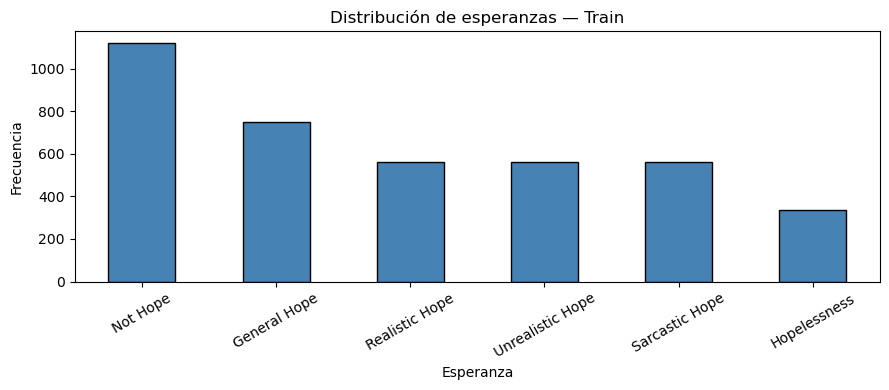

Not Hope            1120
General Hope         749
Realistic Hope       561
Unrealistic Hope     560
Sarcastic Hope       560
Hopelessness         335
dtype: int64


In [8]:
# Distribución de esperanzas en train
dist = hope_distribution(train_df, hope_col=HOPE_COL)

fig, ax = plt.subplots(figsize=(9, 4))
dist.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Distribución de esperanzas — Train")
ax.set_xlabel("Esperanza")
ax.set_ylabel("Frecuencia")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "emotion_distribution.png"), dpi=150)
plt.show()
print(dist)

In [9]:
# ── Pesos positivos para BCEWithLogitsLoss ────────────────────
pos_weights_np = compute_class_weights(train_df, HOPE_COL, labels=PRIMARY_LABELS)
pos_weight = torch.tensor(pos_weights_np) if USE_POS_WEIGHT else None

print("Pesos positivos por clase:")
for label, w in zip(PRIMARY_LABELS, pos_weights_np):
    print(f"  {label:12s}: {w:.2f}")

Pesos positivos por clase:
  General Hope: 3884.00
  Realistic Hope: 3884.00
  Unrealistic Hope: 3884.00
  Sarcastic Hope: 3884.00
  Hopelessness: 3884.00
  Not Hope    : 3884.00


## 4. Tokenizador y DataLoaders

In [10]:
tokenizer = build_tokenizer(MODEL_NAME)
print(f"Tokenizer cargado: {MODEL_NAME}")

# Verificar longitudes reales de los textos
sample_lengths = [
    len(tokenizer.encode(t, add_special_tokens=True))
    for t in train_texts[:500]
]
print(f"Longitud media tokens (muestra 500): {np.mean(sample_lengths):.1f}")
print(f"Percentil 95: {np.percentile(sample_lengths, 95):.0f}")
print(f"Máximo: {max(sample_lengths)}")
print(f"MAX_LENGTH configurado: {MAX_LENGTH}")

Tokenizer cargado: microsoft/mdeberta-v3-base
Longitud media tokens (muestra 500): 332.8
Percentil 95: 770
Máximo: 5954
MAX_LENGTH configurado: 512


In [11]:
loaders = build_all_dataloaders(
    train_texts=train_texts,
    train_labels=train_labels,
    dev_texts=dev_texts,
    dev_labels=dev_labels,
    tokenizer=tokenizer,
    test_texts=test_texts,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

print(f"Batches — Train: {len(loaders['train'])} | Dev: {len(loaders['dev'])}", end="")
if "test" in loaders:
    print(f" | Test: {len(loaders['test'])}")
else:
    print()

# Verificar un batch
sample_batch = next(iter(loaders["train"]))
print("\nForma de un batch:")
for k, v in sample_batch.items():
    print(f"  {k}: {v.shape}")

Batches — Train: 243 | Dev: 61 | Test: 131

Forma de un batch:
  input_ids: torch.Size([16, 512])
  attention_mask: torch.Size([16, 512])
  token_type_ids: torch.Size([16, 512])
  labels: torch.Size([16, 6])


## 5. Comparación de Modelos


In [12]:
# Listar candidatos multilingüe disponibles
list_candidate_models(multilingual_only=True)

# Seleccionar modelos multilingüe para la comparación rápida
candidate_names = [m["name"] for m in CANDIDATE_MODELS if m["multilingual"]]

# Comparar arquitecturas con COMPARISON_EPOCHS épocas cada una
comparison_results = compare_models(
    model_names=candidate_names,
    train_loader=loaders["train"],
    dev_loader=loaders["dev"],
    device=DEVICE,
    num_labels=NUM_LABELS,
    num_epochs=COMPARISON_EPOCHS,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
    pos_weight=pos_weight,
    save_dir=COMPARISON_DIR,
    monitor_metric="f1_macro",
    early_stopping_patience=2,
)

BEST_ARCH = comparison_results.iloc[0]["model"]
print(f"\nMejor arquitectura: {BEST_ARCH}")
print(
    f"   F1 Macro (exploración {COMPARISON_EPOCHS} épocas): "
    f"{comparison_results.iloc[0]['f1_macro']:.4f}"
)


Modelo                                        Multilingüe    Descripción
----------------------------------------------------------------------------------------------------
microsoft/mdeberta-v3-base                    ✓              mDeBERTa v3 – fuerte en tareas multilingüe, mejor baseline general
xlm-roberta-base                              ✓              XLM-RoBERTa base – robusto, ampliamente usado en NLP multilingüe
xlm-roberta-large                             ✓              XLM-RoBERTa large – mayor capacidad, requiere más VRAM
bert-base-multilingual-cased                  ✓              mBERT cased – baseline clásico multilingüe

  Evaluando: microsoft/mdeberta-v3-base


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias            | UNEXPECTED |  | 
mask_predictions.dense.bias                | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED |  | 
lm_predictions.lm_head.bias                | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED |  | 
mask_predictions.classifier.weight         | UNEXPECTED |  | 
mask_predictions.dense.weight              | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED |  | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED |  | 
mask_predictions.classifier.bias           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/ar

Iniciando entrenamiento: 3 épocas, lr=2e-05
- Total steps: 729 | Warmup steps: 72
- Early stopping: patience=2, monitor='f1_macro'

Época 1/3  [103.1s]
- Train Loss: 56.5534  |  Dev Loss: 119.1802
- Dev f1_macro: 0.4346
Modelo guardado en ./outputs/model_comparison_task_a/microsoft_mdeberta-v3-base_best.pt
Nuevo mejor modelo guardado (f1_macro=0.4346)

Época 2/3  [112.8s]
- Train Loss: 9.9648  |  Dev Loss: 17.9431
- Dev f1_macro: 0.5272
Modelo guardado en ./outputs/model_comparison_task_a/microsoft_mdeberta-v3-base_best.pt
Nuevo mejor modelo guardado (f1_macro=0.5272)

Época 3/3  [113.2s]
- Train Loss: 5.7107  |  Dev Loss: 14.1553
- Dev f1_macro: 0.6336
Modelo guardado en ./outputs/model_comparison_task_a/microsoft_mdeberta-v3-base_best.pt
Nuevo mejor modelo guardado (f1_macro=0.6336)

- Entrenamiento finalizado. Mejor f1_macro: 0.6336

  Evaluando: xlm-roberta-base


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iniciando entrenamiento: 3 épocas, lr=2e-05
- Total steps: 729 | Warmup steps: 72
- Early stopping: patience=2, monitor='f1_macro'

Época 1/3  [228.9s]
- Train Loss: 40.0750  |  Dev Loss: 5.9462
- Dev f1_macro: 0.5315
Modelo guardado en ./outputs/model_comparison_task_a/xlm-roberta-large_best.pt
Nuevo mejor modelo guardado (f1_macro=0.5315)

Época 2/3  [238.1s]
- Train Loss: 11.7907  |  Dev Loss: 5.5511
- Dev f1_macro: 0.7766
Modelo guardado en ./outputs/model_comparison_task_a/xlm-roberta-large_best.pt
Nuevo mejor modelo guardado (f1_macro=0.7766)

Época 3/3  [253.3s]
- Train Loss: 9.5982  |  Dev Loss: 8.1181
- Dev f1_macro: 0.8524
Modelo guardado en ./outputs/model_comparison_task_a/xlm-roberta-large_best.pt
Nuevo mejor modelo guardado (f1_macro=0.8524)

- Entrenamiento finalizado. Mejor f1_macro: 0.8524

  Evaluando: bert-base-multilingual-cased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iniciando entrenamiento: 3 épocas, lr=2e-05
- Total steps: 729 | Warmup steps: 72
- Early stopping: patience=2, monitor='f1_macro'

Época 1/3  [85.3s]
- Train Loss: 55.9810  |  Dev Loss: 85.6311
- Dev f1_macro: 0.4785
Modelo guardado en ./outputs/model_comparison_task_a/bert-base-multilingual-cased_best.pt
Nuevo mejor modelo guardado (f1_macro=0.4785)

Época 2/3  [85.3s]
- Train Loss: 6.5885  |  Dev Loss: 9.5505
- Dev f1_macro: 0.6110
Modelo guardado en ./outputs/model_comparison_task_a/bert-base-multilingual-cased_best.pt
Nuevo mejor modelo guardado (f1_macro=0.6110)

Época 3/3  [62.4s]
- Train Loss: 7.6448  |  Dev Loss: 26.3993
- Dev f1_macro: 0.7165
Modelo guardado en ./outputs/model_comparison_task_a/bert-base-multilingual-cased_best.pt
Nuevo mejor modelo guardado (f1_macro=0.7165)

- Entrenamiento finalizado. Mejor f1_macro: 0.7165

  Ranking final de modelos
                       model  f1_macro  best_epoch  train_loss  dev_loss status
           xlm-roberta-large    0.8524     

## 6. Entrenamiento Completo del Mejor Modelo

Entrenamos `BEST_ARCH` con `NUM_EPOCHS` épocas completas y early stopping.


In [13]:
# Construir el modelo ganador desde cero
model = build_model(
    model_name=BEST_ARCH,
    num_labels=NUM_LABELS,
    dropout_prob=DROPOUT,
)
model = model.float()

n_params = count_parameters(model)
print(f"Arquitectura: {BEST_ARCH}")
print(f"Parámetros entrenables: {n_params:,}")
print(f"Cabeza clasificadora: {NUM_LABELS} etiquetas")


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Arquitectura: xlm-roberta-large
Parámetros entrenables: 559,896,582
Cabeza clasificadora: 6 etiquetas


In [14]:
# Reconstruir tokenizer y loaders con la arquitectura ganadora
tokenizer = build_tokenizer(BEST_ARCH)
loaders = build_all_dataloaders(
    train_texts=train_texts,
    train_labels=train_labels,
    dev_texts=dev_texts,
    dev_labels=dev_labels,
    tokenizer=tokenizer,
    test_texts=test_texts,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=0,
)
print(f"Loaders reconstruidos con tokenizer de: {BEST_ARCH}")


Loaders reconstruidos con tokenizer de: xlm-roberta-large


In [15]:
history = train(
    model=model,
    train_loader=loaders["train"],
    dev_loader=loaders["dev"],
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
    pos_weight=pos_weight,
    save_dir=OUTPUT_DIR,
    model_name=BEST_MODEL_NAME,
    early_stopping_patience=PATIENCE,
    monitor_metric="f1_macro",
    verbose=True,
)

Iniciando entrenamiento: 25 épocas, lr=2e-05
- Total steps: 6075 | Warmup steps: 607
- Early stopping: patience=3, monitor='f1_macro'

Época 1/25  [238.6s]
- Train Loss: 70.0141  |  Dev Loss: 67.4523
- Dev f1_macro: 0.4419
Modelo guardado en ./outputs/best_model_task_a.pt
Nuevo mejor modelo guardado (f1_macro=0.4419)

Época 2/25  [238.5s]
- Train Loss: 12.1687  |  Dev Loss: 9.5923
- Dev f1_macro: 0.7144
Modelo guardado en ./outputs/best_model_task_a.pt
Nuevo mejor modelo guardado (f1_macro=0.7144)

Época 3/25  [237.5s]
- Train Loss: 20.1634  |  Dev Loss: 5.5185
- Dev f1_macro: 0.8357
Modelo guardado en ./outputs/best_model_task_a.pt
Nuevo mejor modelo guardado (f1_macro=0.8357)

Época 4/25  [238.5s]
- Train Loss: 18.8129  |  Dev Loss: 38.5951
- Dev f1_macro: 0.8737
Modelo guardado en ./outputs/best_model_task_a.pt
Nuevo mejor modelo guardado (f1_macro=0.8737)

Época 5/25  [237.3s]
- Train Loss: 30.6792  |  Dev Loss: 130.6384
- Dev f1_macro: 0.8918
Modelo guardado en ./outputs/best_mode

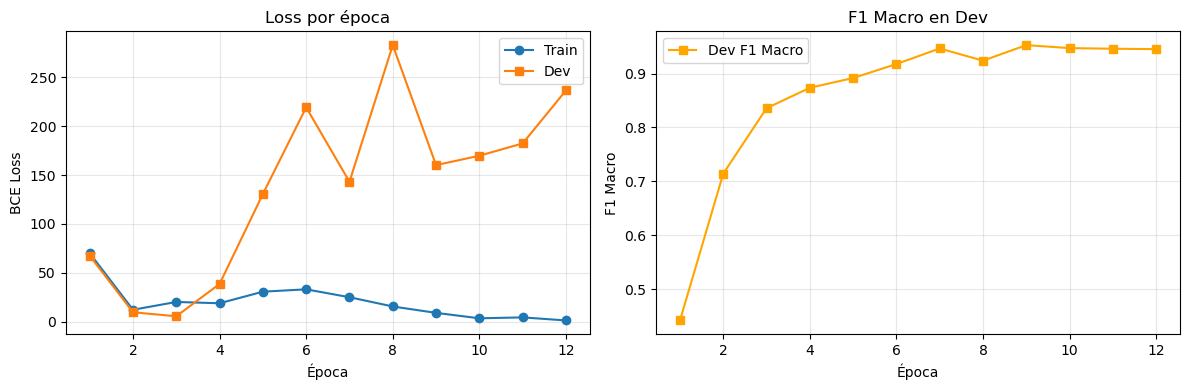

In [16]:
# ── Curvas de entrenamiento ───────────────────────────────────
epochs_run = range(1, len(history["train_loss"]) + 1)
dev_f1 = [m.get("f1_macro", 0) for m in history["dev_metrics"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs_run, history["train_loss"], label="Train", marker="o")
axes[0].plot(epochs_run, history["dev_loss"],   label="Dev",   marker="s")
axes[0].set_title("Loss por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 Macro
axes[1].plot(epochs_run, dev_f1, label="Dev F1 Macro", marker="s", color="orange")
axes[1].set_title("F1 Macro en Dev")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("F1 Macro")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()

## 7. Evaluación del Mejor Modelo en Dev

In [17]:
# Cargar el mejor checkpoint guardado
best_model = load_model(
    path=os.path.join(OUTPUT_DIR, BEST_MODEL_NAME),
    model_name=BEST_ARCH,
    num_labels=NUM_LABELS,
    dropout_prob=DROPOUT,
    device=DEVICE,
)

best_model = best_model.float()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado desde ./outputs/best_model_task_a.pt


In [18]:
# Obtener probabilidades en dev
_, _, dev_probs, dev_true = evaluate_epoch(
    best_model, loaders["dev"], DEVICE, threshold=THRESHOLD
)

print(f"Formas — probs: {dev_probs.shape} | labels: {dev_true.shape}")

Formas — probs: (972, 6) | labels: (972, 6)


In [19]:
# ── Métricas con umbral por defecto (0.5) ─────────────────────
print("=== Evaluación con threshold=max ===")
metrics = compute_metrics(dev_true, dev_probs, threshold=True, label_names=PRIMARY_LABELS)
print_metrics(metrics)

print("\n" + classification_report_str(dev_true, dev_probs, threshold=0.5, label_names=PRIMARY_LABELS))

=== Evaluación con threshold=max ===
  F1 Macro:    0.9523
  F1 Micro:    0.9558
  F1 Weighted: 0.9552
  Precision:   0.9581
  Recall:      0.9476
  Hamming Loss:0.0147
  Threshold:   1.00
--------------------------------------------------
  F1 por etiqueta:

                  precision    recall  f1-score   support

    General Hope       0.96      1.00      0.98       188
  Realistic Hope       0.90      0.87      0.89       140
Unrealistic Hope       0.97      0.99      0.98       140
  Sarcastic Hope       0.97      0.96      0.96       140
    Hopelessness       0.94      0.96      0.95        84
        Not Hope       0.92      0.99      0.96       280

       micro avg       0.94      0.97      0.95       972
       macro avg       0.95      0.96      0.95       972
    weighted avg       0.94      0.97      0.95       972
     samples avg       0.95      0.97      0.96       972



## 8. Análisis de Errores

In [20]:
from src.metrics import binarize

dev_pred = binarize(dev_probs, True)

# Ejemplos mal clasificados
errors = []
for i in range(len(dev_texts)):
    true_hope = PRIMARY_LABELS[np.where(dev_true[i] == 1)[0][0]]
    pred_hope = PRIMARY_LABELS[np.where(dev_pred[i] == 1)[0][0]]
    if true_hope != pred_hope:
        errors.append({
            "text":  dev_texts[i],
            "true":  true_hope,
            "pred":  pred_hope,
        })

error_rate = len(errors) / len(dev_texts) * 100
print(f"Muestras con al menos 1 error: {len(errors)} ({error_rate:.1f}%)")
print()

# Mostrar primeros 5 errores
for e in errors[:5]:
    print(f"Texto: {e['text'][:100]}...")
    print(f"  Real: {e['true']}")
    print(f"  Pred: {e['pred']}")
    print()

Muestras con al menos 1 error: 43 (4.4%)

Texto: No hay sentido en lo que siento o no lo encuentro. Me siento inútil y un estorbo, verán he pasado po...
  Real: Hopelessness
  Pred: Realistic Hope

Texto: After I thought I was graduating, my advisor tells me I’m not. I’ve been in shambles all day since l...
  Real: Hopelessness
  Pred: General Hope

Texto: Will ignoring my chronic pain symptoms finally make them disappear?. I've been dealing with persiste...
  Real: Sarcastic Hope
  Pred: General Hope

Texto: There is nothing more painful than feeling bad when everyone else feels good. Just today I saw a com...
  Real: Hopelessness
  Pred: Not Hope

Texto: Accountability Partner. Hola, estoy buscando un Accountability Partner de estudio. Estudio 12 horas ...
  Real: Not Hope
  Pred: Realistic Hope



## 9. Generación de Predicciones para Test (Submission)

In [21]:
print("Generando predicciones para test...")
test_probs = predict(best_model, loaders["test"], DEVICE)
print(f"Probabilidades test: {test_probs.shape}")

Generando predicciones para test...
Probabilidades test: (2082, 6)


In [22]:
# Usar el umbral óptimo encontrado en dev
submission_df = format_predictions_for_submission_hope(
        ids=test_ids,
        predictions=test_probs,
        label_set=PRIMARY_LABELS,
    )

print(f"Submission — primeras filas:")
print(submission_df.head())
print(f"\nDistribución de predicciones en test:")
all_preds = [hope for hope in submission_df["primary_label"]]
from collections import Counter
print(Counter(all_preds))

Submission — primeras filas:
     id   primary_label
0    17  Sarcastic Hope
1  3512        Not Hope
2  4863        Not Hope
3  6917    General Hope
4  8586  Sarcastic Hope

Distribución de predicciones en test:
Counter({'Not Hope': 617, 'General Hope': 394, 'Sarcastic Hope': 309, 'Unrealistic Hope': 299, 'Realistic Hope': 283, 'Hopelessness': 180})


In [23]:
submission_path = os.path.join(OUTPUT_DIR, "submission_task_a.json")
save_submission(submission_df, submission_path)
print(f"✅ Submission lista para subir a CodaBench: {submission_path}")

Submission guardada en ./outputs/submission_task_a.json
✅ Submission lista para subir a CodaBench: ./outputs/submission_task_a.json


## 10. Guardado del Experimento

In [24]:
experiment_config = {
    "model_name":        BEST_ARCH,
    "base_model_name":   MODEL_NAME,
    "max_length":        MAX_LENGTH,
    "batch_size":        BATCH_SIZE,
    "comparison_epochs": COMPARISON_EPOCHS,
    "learning_rate":     LR,
    "warmup_ratio":      WARMUP_RATIO,
    "weight_decay":      WEIGHT_DECAY,
    "dropout":           DROPOUT,
    "use_pos_weight":    USE_POS_WEIGHT,
    "seed":              SEED,
    "comparison_dir":    COMPARISON_DIR,
    "best_dev_f1_macro": float(metrics["f1_macro"]),
    "dev_metrics":       {k: float(v) for k, v in metrics.items()},
}

config_path = os.path.join(OUTPUT_DIR, "experiment_config.json")
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)

print("✅ Configuración del experimento guardada:")
print(json.dumps(experiment_config, indent=2))

✅ Configuración del experimento guardada:
{
  "model_name": "xlm-roberta-large",
  "base_model_name": "microsoft/mdeberta-v3-base",
  "max_length": 512,
  "batch_size": 16,
  "comparison_epochs": 3,
  "learning_rate": 2e-05,
  "warmup_ratio": 0.1,
  "weight_decay": 0.01,
  "dropout": 0.1,
  "use_pos_weight": true,
  "seed": 42,
  "comparison_dir": "./outputs/model_comparison_task_a",
  "best_dev_f1_macro": 0.9522994127437779,
  "dev_metrics": {
    "f1_macro": 0.9522994127437779,
    "f1_micro": 0.9557613168724279,
    "f1_weighted": 0.9551881394401498,
    "precision_macro": 0.958081284744924,
    "recall_macro": 0.9476190476190477,
    "hamming_loss": 0.014746227709190672,
    "threshold": 1.0,
    "f1_General Hope": 0.9842931937172775,
    "f1_Realistic Hope": 0.8838951310861424,
    "f1_Unrealistic Hope": 0.9822064056939501,
    "f1_Sarcastic Hope": 0.9672727272727273,
    "f1_Hopelessness": 0.9397590361445783,
    "f1_Not Hope": 0.956369982547993
  }
}
